In [20]:
import geomodel_toolbox
import importlib

importlib.reload(geomodel_toolbox)

<module 'geomodel_toolbox' from 'c:\\Users\\ethan\\MSc-Thesis\\GeoModel\\geomodel_toolbox.py'>

In [3]:
import numpy as np
import pandas as pd

In [4]:
#  ====
# Inputs for creating strat model with gempy
#  ====
#dummy: xyz values are taken from gempy outputs
x_lims = (369702.8, 374398.9)
y_lims = (407778.9, 411690.2)
z_lims = (350, -2000)

resolution = [100, 100, 60]   # nx, ny, nz
 
strat_azimuth = 135 #deg
strat_dip = 10 #deg

#  ====
# Inputs for fracture map
#  ====

aperture = [50, 50] #[m] [MEAN, STD]
radius = [1000, 100] #[m] [MEAN, STD]
azimuth = [45, 10] #[deg] [MEAN, STD]

density = 5e-9 #[fractures/m3]

In [5]:
#geomodel_toolbox.create_strat_model(x_lims, y_lims, z_lims, resolution, strat_azimuth, strat_dip)

c:\Users\ethan\MSc-Thesis\GeoModel\geomodel_toolbox.py:266: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


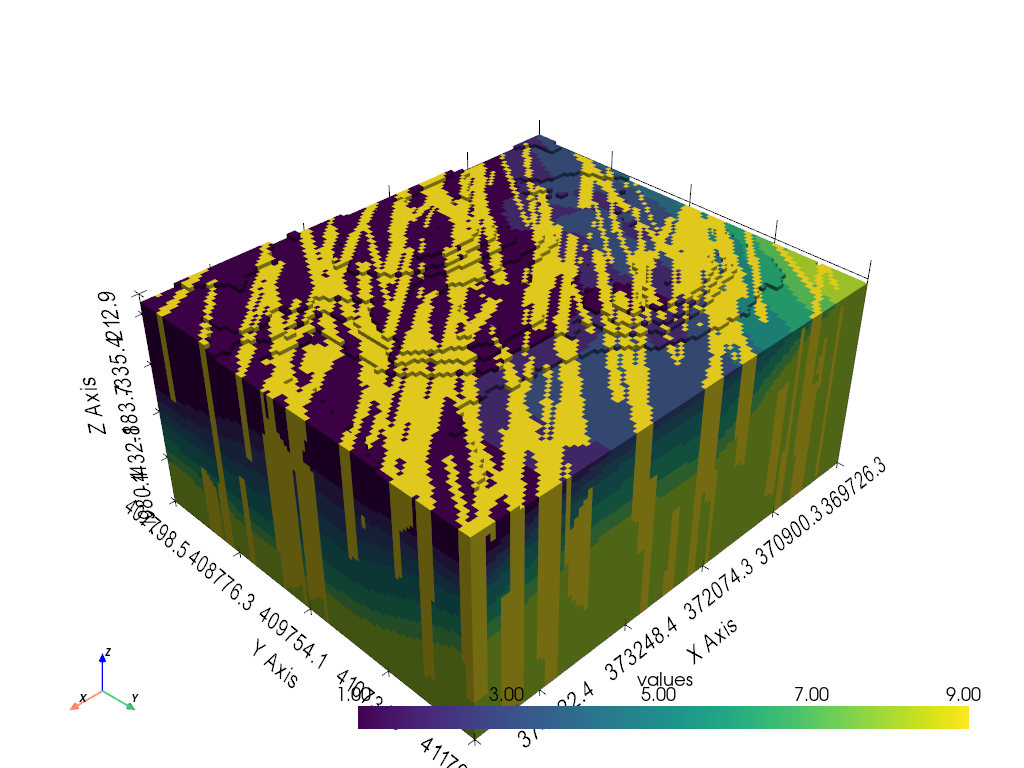

In [6]:
# Import previously defined topo+strat model
lith_topo, x_array, y_array, z_array= geomodel_toolbox.import_strat_model(show_plot=False)

# Generate fracture model based on inputs
mask, df = geomodel_toolbox.generate_fracture_model(x_array, y_array, z_array, aperture, radius, azimuth, density, show_plot=False)

# Combine to get topo+strat+frac model
geomodel = lith_topo.copy()
geomodel[(lith_topo > 0) & mask] = lith_topo.max()+1

# Plot results
geomodel_toolbox.plot_3d_model(geomodel, x_array, y_array, z_array)

In [21]:
# Define rock properties for easy access
ROCK_TYPES = {
    "M": {"poro": 0.2, "permx": 50},
    "B": {"poro": 0.02, "permx": 1e-2},
    "F": {"poro": 0.1, "permx": 1e3}
}

# Export to grid eclipse
grid = geomodel_toolbox.export_grdecl_from_geomodel(
    geomodel=geomodel,
    x_array=x_array,
    y_array=y_array,
    z_array=z_array,
    rock_types=ROCK_TYPES,
    out_file="grid.grdecl"
)

In [8]:
print(x_array[0]-x_array[1])
print(y_array[0]-y_array[1])
print(z_array[0]-z_array[1])

-46.961000000010245
-39.11300000001211
-39.16666666666674


In [18]:
import rasterio
import numpy as np

with rasterio.open("subset_dem.tif") as src:
    dem = src.read(1)

    if src.nodata is not None:
        dem = np.where(dem == src.nodata, np.nan, dem)

    print("DEM statistics")
    print("----------------")
    print(f"Min   : {np.nanmin(dem):.2f}")
    print(f"Max   : {np.nanmax(dem):.2f}")
    print(f"Mean  : {np.nanmean(dem):.2f}")
    print(f"Std   : {np.nanstd(dem):.2f}")
    print(f"NoData: {src.nodata}")
    print(f"Shape : {dem.shape}")

DEM statistics
----------------
Min   : 8.13
Max   : 267.06
Mean  : 110.53
Std   : 61.89
NoData: -3.4028234663852886e+38
Shape : (391, 469)


In [19]:
print(z_array)

[-1980.41666667 -1941.25       -1902.08333333 -1862.91666667
 -1823.75       -1784.58333333 -1745.41666667 -1706.25
 -1667.08333333 -1627.91666667 -1588.75       -1549.58333333
 -1510.41666667 -1471.25       -1432.08333333 -1392.91666667
 -1353.75       -1314.58333333 -1275.41666667 -1236.25
 -1197.08333333 -1157.91666667 -1118.75       -1079.58333333
 -1040.41666667 -1001.25        -962.08333333  -922.91666667
  -883.75        -844.58333333  -805.41666667  -766.25
  -727.08333333  -687.91666667  -648.75        -609.58333333
  -570.41666667  -531.25        -492.08333333  -452.91666667
  -413.75        -374.58333333  -335.41666667  -296.25
  -257.08333333  -217.91666667  -178.75        -139.58333333
  -100.41666667   -61.25         -22.08333333    17.08333333
    56.25          95.41666667   134.58333333   173.75
   212.91666667   252.08333333   291.25         330.41666667]


In [33]:
# Just for visualisation

import pandas as pd
import rasterio

# Read wells
wells = pd.read_csv("gempy_inputs/borehole_data.csv")

# Sample DEM elevations
with rasterio.open("subset_dem.tif") as dem:
    coords = list(zip(wells["x"], wells["y"]))
    elevations = [v[0] for v in dem.sample(coords)]

wells["surface_z"] = elevations

# Bottom elevation = surface elevation - depth
wells["bottom_z"] = wells["surface_z"] - wells["depth"]

# Write ResInsight-style well path file
with open("vertical_wells.dev", "w") as f:

    for _, row in wells.iterrows():

        f.write(f"WELLNAME: {row['name']}\n")

        # Wellhead
        f.write(
            f"{row['x']:.2f} "
            f"{row['y']:.2f} "
            f"{row['surface_z']:.2f}\n"
        )

        # Vertical bottom
        f.write(
            f"{row['x']:.2f} "
            f"{row['y']:.2f} "
            f"{row['bottom_z']:.2f}\n\n"
        )

print("Created vertical_wells.dev")

Created vertical_wells.dev


In [42]:
import pandas as pd
import rasterio

# Read wells
wells = pd.read_csv("gempy_inputs/borehole_data.csv")

# Sample DEM elevations
with rasterio.open("subset_dem.tif") as dem:
    coords = list(zip(wells["x"], wells["y"]))
    elevations = [v[0] for v in dem.sample(coords)]

wells["surface_z"] = elevations

# Bottom elevation = surface elevation - depth
wells["bottom_z"] = wells["depth"] - wells["surface_z"]

# Write ResInsight-style well path file
with open("vertical_wells.dev", "w") as f:

    for _, row in wells.iterrows():

        f.write(f"WELLNAME: {row['name']}\n")

        # Wellhead
        f.write(
            f"{row['x']:.2f} "
            f"{row['y']:.2f} "
            f"-100.00 "
            #f"{row['surface_z']:.2f} "
            f"0.00\n"
        )

        # Vertical bottom
        f.write(
            f"{row['x']:.2f} "
            f"{row['y']:.2f} "
            f"{row['bottom_z']:.2f} "
            f"{row['depth']:.2f}\n\n"
        )

print("Created vertical_wells.dev")

Created vertical_wells.dev


In [25]:
import pandas as pd
import numpy as np
import rasterio

# ----------------------------
# 1. Load inputs
# ----------------------------
wells = pd.read_csv("gempy_inputs/borehole_data.csv")

dem_path = "subset_dem.tif"
dem_src = rasterio.open(dem_path)

# ----------------------------
# 2. Helper: sample DEM
# ----------------------------
def get_dem_elevation(x, y):
    """Return DEM elevation at (x,y)."""
    row, col = dem_src.index(x, y)
    return dem_src.read(1)[row, col]


# ----------------------------
# 3. Grid helpers
# ----------------------------
dx = x_array[1] - x_array[0]
dy = y_array[1] - y_array[0]
dz = z_array[1] - z_array[0]

# z_array is assumed to be the CROPPED version
# exported to GRDECL, e.g.
#
# [0, -10, -20, -30, ...]
#
# K=1 corresponds to the first layer in this array.

def xyz_to_ijk(x, y, z):
    """Convert coordinates to Eclipse-style 1-based indices."""

    i = int(np.argmin(np.abs(x_array - x))) + 1
    j = int(np.argmin(np.abs(y_array - y))) + 1
    k = int(np.argmin(np.abs(z_array - z))) + 1

    return i, j, k


# ----------------------------
# 4. Convert well intervals
# ----------------------------
completions = []

for _, w in wells.iterrows():

    name = w["name"]
    x = w["x"]
    y = w["y"]

    # depths below surface
    z_top = w["casing"]
    z_bottom = w["depth"]

    # DEM elevation at wellhead
    z_surface = get_dem_elevation(x, y)

    # convert to absolute elevations
    z_top_abs = z_surface - z_top
    z_bot_abs = z_surface - z_bottom

    z_high = max(z_top_abs, z_bot_abs)
    z_low = min(z_top_abs, z_bot_abs)

    # --------------------------------------------------
    # exported model only contains z <= 0
    # --------------------------------------------------

    # skip wells entirely above datum
    if z_low > 0:
        continue

    # truncate completion if top is above datum
    z_high = min(z_high, 0.0)

    # convert to K indices
    k1 = int(np.argmin(np.abs(z_array - z_high))) + 1
    k2 = int(np.argmin(np.abs(z_array - z_low))) + 1

    if k1 > k2:
        k1, k2 = k2, k1

    # ensure indices stay inside model
    k1 = max(1, min(k1, len(z_array)))
    k2 = max(1, min(k2, len(z_array)))

    # I/J location
    i, j, _ = xyz_to_ijk(x, y, z_array[0])

    completions.append((name, i, j, k1, k2))


# ----------------------------
# 5. Write Eclipse COMPDAT file
# ----------------------------
with open("sch.inc", "w") as f:

    f.write("--perforations in Eclipse format I, J, K1-K2, 1-based indices\n")
    f.write("COMPDAT\n")

    for name, i, j, k1, k2 in completions:
        f.write(f"PRD-{name} {i} {j} {k1} {k2} /\n")

    f.write("/\n")

print(f"sch.inc written with {len(completions)} completions.")

sch.inc written with 37 completions.
